# DG4NLP Natural Language Processing
## Week 1 Coursework — Section 1: Data Exploration & Preprocessing

**Module:** DG4NLP Natural Language Processing  
**Instructor:** Dr Amal Htait  
**Author:** [Your Name]

---

## Introduction

### The ArXiv Dataset
ArXiv is a free, open-access repository where researchers share scientific papers before official publication. It hosts over **1.7 million articles** across fields including physics, computer science, mathematics, statistics, biology, and economics.

The dataset is available on Kaggle as a metadata snapshot in newline-delimited JSON format. Each record contains:
- `id` — unique ArXiv identifier
- `title` — paper title
- `abstract` — paper summary
- `categories` — one or more subject tags (e.g. `cs.LG`, `math.AP`)
- `authors`, `submitter`, `doi`, `journal-ref`, `comments`, `versions`

### Purpose of This Stage
This notebook covers **initial data exploration and preprocessing** — the essential foundation before any machine learning work. We will:
1. Load and inspect the dataset structure
2. Handle multi-label categories by extracting a single primary label
3. Clean and normalise the text fields
4. Encode category labels as integers
5. Export a clean CSV ready for ML

### Potential Future Applications
- **Category classification** — predict which research field a paper belongs to from its title/abstract
- **Summarisation** — generate a short title from a full abstract
- **Recommendation systems** — suggest related papers
- **Search & knowledge graphs** — index papers for semantic search

---
## 0. Imports

In [1]:
import json
import re
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from collections import Counter

# Consistent plot style throughout the notebook
sns.set_theme(style="whitegrid", palette="muted")
%matplotlib inline

print("All imports successful.")

All imports successful.


---
## Step 1: Load and Explore the Data

The dataset is stored as **newline-delimited JSON** — one JSON object per line (not a JSON array).  
We read it lazily line-by-line to avoid loading the full ~4 GB file into memory at once.

> **Tip:** Set `MAX_ROWS = None` to process the entire dataset. Use a smaller number (e.g. `200_000`) for faster experimentation.

In [2]:
import os, json as _json, pandas as pd

SEARCH_PATHS = [
    os.path.join(os.getcwd(), "arxiv-metadata-oai-snapshot.json"),
    r"C:\Users\Mahesh Reddy\Downloads\arxiv-metadata-oai-snapshot.json",
    r"C:\Users\Mahesh Reddy\Downloads\Assignment nlp\arxiv-metadata-oai-snapshot.json",
]

json_path = None
for p in SEARCH_PATHS:
    if os.path.exists(p):
        json_path = p
        break

if json_path is None:
    raise FileNotFoundError("Paste arxiv-metadata-oai-snapshot.json into the Assignment nlp folder")

print("Found dataset at:", json_path)

MAX_ROWS = 200_000

records = []
print(f"Loading first {MAX_ROWS:,} records...")
with open(json_path, "r", encoding="utf-8") as fh:
    for i, line in enumerate(fh):
        if MAX_ROWS and i >= MAX_ROWS:
            break
        records.append(_json.loads(line))

df = pd.DataFrame(records)
print(f"Loaded {len(df):,} papers.")
df.head(3)

Found dataset at: C:\Users\Mahesh Reddy\Downloads\Assignment nlp\arxiv-metadata-oai-snapshot.json
Loading first 200,000 records...
Loaded 200,000 papers.


,id,submitter,authors,title,comments,journal-ref,doi,report-no,categories,license,abstract,versions,update_date,authors_parsed
0,0704.0001,Pavel Nadolsky,"C. Bal\'azs, E. L. Berger, P. M. Nadolsky, C.-...",Calculation of prompt diphoton production cros...,"37 pages, 15 figures; published version","Phys.Rev.D76:013009,2007",10.1103/PhysRevD.76.013009,ANL-HEP-PR-07-12,hep-ph,None,A fully differential calculation in perturba...,"[{'version': 'v1', 'created': 'Mon, 2 Apr 2007...",2008-11-26,"[[Balázs, C., ], [Berger, E. L., ], [Nadolsky,..."
1,0704.0002,Louis Theran,Ileana Streinu and Louis Theran,Sparsity-certifying Graph Decompositions,To appear in Graphs and Combinatorics,None,None,None,math.CO cs.CG,http://arxiv.org/licenses/nonexclusive-distrib...,"We describe a new algorithm, the $(k,\ell)$-...","[{'version': 'v1', 'created': 'Sat, 31 Mar 200...",2008-12-13,"[[Streinu, Ileana, ], [Theran, Louis, ]]"
2,0704.0003,Hongjun Pan,Hongjun Pan,The evolution of the Earth-Moon system based o...,"23 pages, 3 figures",None,None,None,physics.gen-ph,None,The evolution of Earth-Moon system is descri...,"[{'version': 'v1', 'created': 'Sun, 1 Apr 2007...",2008-01-13,"[[Pan, Hongjun, ]]"


In [3]:
# ── Shape and column names ──
print(f"Shape  : {df.shape}")
print(f"Columns: {list(df.columns)}")

Shape  : (200000, 14)
Columns: ['id', 'submitter', 'authors', 'title', 'comments', 'journal-ref', 'doi', 'report-no', 'categories', 'license', 'abstract', 'versions', 'update_date', 'authors_parsed']


In [4]:
# ── Data types ──
df.dtypes

id                object
submitter         object
authors           object
title             object
comments          object
journal-ref       object
doi               object
report-no         object
categories        object
license           object
abstract          object
versions          object
update_date       object
authors_parsed    object
dtype: object

In [5]:
# ── Missing values per column ──
missing = df.isnull().sum()
print("Missing values:")
print(missing[missing > 0] if missing.any() else "No missing values found.")

Missing values:
comments        28130
journal-ref     99319
doi             78491
report-no      182320
license         43217
dtype: int64


In [6]:
# ── Unique category tags across all papers ──
# Each 'categories' entry is a space-separated string, e.g. "cs.LG stat.ML"
all_cats_raw = df["categories"].dropna().str.split().explode()
unique_cats  = all_cats_raw.unique()
print(f"Unique individual category tags: {len(unique_cats)}")
print("Sample tags:", sorted(unique_cats)[:20])

Unique individual category tags: 153
Sample tags: ['astro-ph', 'astro-ph.CO', 'astro-ph.EP', 'astro-ph.GA', 'astro-ph.HE', 'astro-ph.IM', 'astro-ph.SR', 'cond-mat.dis-nn', 'cond-mat.mes-hall', 'cond-mat.mtrl-sci', 'cond-mat.other', 'cond-mat.quant-gas', 'cond-mat.soft', 'cond-mat.stat-mech', 'cond-mat.str-el', 'cond-mat.supr-con', 'cs.AI', 'cs.AR', 'cs.CC', 'cs.CE']


---
## Step 2: Handle Categories (Labels)

Each paper can have **multiple categories**. For classification we need a single label per paper.  
**Strategy:** Take the *first* listed category (ArXiv convention = primary category), then strip the sub-field suffix to get a broad top-level domain:

| Raw `categories` | First tag | Main category |
|---|---|---|
| `cs.LG stat.ML` | `cs.LG` | `cs` |
| `math.AP math.CA` | `math.AP` | `math` |
| `hep-th` | `hep-th` | `hep-th` |

In [7]:
def extract_main_category(cat_string):
    """
    Extract the top-level domain from an ArXiv category string.
    Returns the first tag's prefix before the dot, e.g. 'cs.LG' → 'cs'.
    """
    if pd.isna(cat_string) or cat_string.strip() == "":
        return np.nan
    first = cat_string.strip().split()[0]   # first listed category
    return first.split(".")[0]              # strip sub-field

df["main_category"] = df["categories"].apply(extract_main_category)

print("Top-level category value counts:")
df["main_category"].value_counts()

Top-level category value counts:


main_category
math        42665
astro-ph    34767
cond-mat    33271
physics     13493
hep-ph      13457
cs          13249
hep-th      10997
quant-ph    10296
gr-qc        6363
math-ph      4396
nucl-th      3566
hep-ex       2794
nlin         2364
q-bio        2285
hep-lat      1765
nucl-ex      1698
stat         1489
q-fin        1085
Name: count, dtype: int64

In [8]:
# Drop rows where category, title, or abstract is missing
before = len(df)
df.dropna(subset=["main_category", "abstract", "title"], inplace=True)
after  = len(df)
print(f"Rows before: {before:,}  |  After dropping missing: {after:,}  |  Removed: {before - after}")

Rows before: 200,000  |  After dropping missing: 200,000  |  Removed: 0


---
## Step 3 & 4: Text Preprocessing

We clean both `title` and `abstract` with the following steps:
1. **Lower-case** all text
2. **Replace LaTeX math** (`$...$`, `\begin{equation}`) with a `<MATH>` placeholder token
3. **Strip LaTeX commands** while preserving their text arguments where possible
4. **Collapse whitespace** (newlines, tabs, multiple spaces → single space)

Punctuation is *kept* intentionally — tokenisers and transformer models benefit from it.

In [9]:
def clean_text(text: str) -> str:
    """Clean a single text string for NLP use."""
    if pd.isna(text):
        return ""

    # 1. Lower-case
    text = text.lower()

    # 2. Replace LaTeX math blocks with a placeholder
    text = re.sub(r"\$+[^$]*\$+", " <MATH> ", text)
    text = re.sub(
        r"\\begin\{[^}]*\}.*?\\end\{[^}]*\}",
        " <MATH> ", text, flags=re.DOTALL
    )

    # 3. Strip LaTeX commands, keep argument text where possible
    text = re.sub(r"\\[a-zA-Z]+\{([^}]*)\}", r"\1", text)  # \cmd{arg} → arg
    text = re.sub(r"\\[a-zA-Z]+", " ", text)                # bare \cmd  → space

    # 4. Collapse whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text


# Apply to both fields
df["title_clean"]    = df["title"].apply(clean_text)
df["abstract_clean"] = df["abstract"].apply(clean_text)

# Quick sanity check
print("RAW title    :", df["title"].iloc[0])
print("CLEANED title:", df["title_clean"].iloc[0])
print()
print("RAW abstract (first 200 chars):\n", df["abstract"].iloc[0][:200])
print()
print("CLEANED abstract (first 200 chars):\n", df["abstract_clean"].iloc[0][:200])

RAW title    : Calculation of prompt diphoton production cross sections at Tevatron and
  LHC energies
CLEANED title: calculation of prompt diphoton production cross sections at tevatron and lhc energies

RAW abstract (first 200 chars):
   A fully differential calculation in perturbative quantum chromodynamics is
presented for the production of massive photon pairs at hadron colliders. All
next-to-leading order perturbative contributi

CLEANED abstract (first 200 chars):
 a fully differential calculation in perturbative quantum chromodynamics is presented for the production of massive photon pairs at hadron colliders. all next-to-leading order perturbative contribution


---
## Label Encoding

Machine learning models require **numeric labels**. We use `sklearn.LabelEncoder` to map each category string to a unique integer.

In [10]:
le = LabelEncoder()
df["category_encoded"] = le.fit_transform(df["main_category"])

# Build a readable mapping table
label_map = dict(zip(le.classes_, le.transform(le.classes_)))
label_map_df = pd.DataFrame(
    sorted(label_map.items(), key=lambda x: x[1]),
    columns=["category_name", "encoded_value"]
)

print("Category → Integer mapping:")
label_map_df

Category → Integer mapping:


,category_name,encoded_value
0,astro-ph,0
1,cond-mat,1
2,cs,2
3,gr-qc,3
4,hep-ex,4
5,hep-lat,5
6,hep-ph,6
7,hep-th,7
8,math,8
9,math-ph,9


In [11]:
# Save label map for future reference (e.g. decoding model predictions)
label_map_df.to_csv("category_label_map.csv", index=False)
print("Label map saved → category_label_map.csv")

Label map saved → category_label_map.csv


---
## Step 5: Prepare and Export the CSV

The output CSV contains exactly the four required columns:

| Column | Description |
|---|---|
| `paper_id` | ArXiv paper identifier |
| `title` | Cleaned paper title |
| `abstract` | Cleaned abstract |
| `category` | Encoded integer label |

In [12]:
output_df = df[["id", "title_clean", "abstract_clean", "category_encoded"]].copy()
output_df.columns = ["paper_id", "title", "abstract", "category"]

output_path = "arxiv_processed.csv"
output_df.to_csv(output_path, index=False)

print(f"Saved {len(output_df):,} rows → '{output_path}'")
print(f"Columns: {list(output_df.columns)}")
output_df.head()

Saved 200,000 rows → 'arxiv_processed.csv'
Columns: ['paper_id', 'title', 'abstract', 'category']


,paper_id,title,abstract,category
0,0704.0001,calculation of prompt diphoton production cros...,a fully differential calculation in perturbati...,6
1,0704.0002,sparsity-certifying graph decompositions,"we describe a new algorithm, the <MATH> -pebbl...",8
2,0704.0003,the evolution of the earth-moon system based o...,the evolution of earth-moon system is describe...,13
3,0704.0004,a determinant of stirling cycle numbers counts...,we show that a determinant of stirling cycle n...,8
4,0704.0005,from dyadic <MATH> to <MATH>,in this paper we show how to compute the <MATH...,8


In [13]:
# Verify no missing values in output
print("Missing values in output CSV:")
print(output_df.isnull().sum())

Missing values in output CSV:
paper_id    0
title       0
abstract    0
category    0
dtype: int64


---
## Step 6: Analysis & Visualisation

### Visualisation 1 — Category Distribution

This chart shows how many papers fall into each top-level ArXiv category. Understanding the **class balance** is critical before training a classifier — heavily imbalanced classes may require oversampling or weighted loss functions.

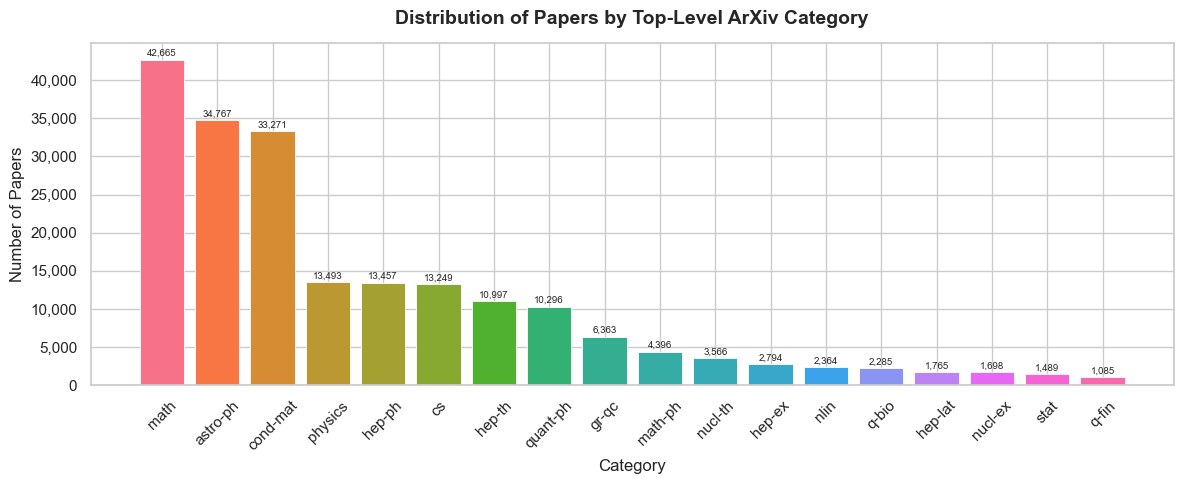

Saved → viz1_category_distribution.png


In [14]:
cat_counts = df["main_category"].value_counts()
colors     = sns.color_palette("husl", len(cat_counts))

fig, ax = plt.subplots(figsize=(12, 5))

bars = ax.bar(cat_counts.index, cat_counts.values, color=colors,
              edgecolor="white", linewidth=0.6)

ax.set_title("Distribution of Papers by Top-Level ArXiv Category",
             fontsize=14, fontweight="bold", pad=14)
ax.set_xlabel("Category", fontsize=12)
ax.set_ylabel("Number of Papers", fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.tick_params(axis="x", rotation=45)

# Annotate each bar with its count
for bar, count in zip(bars, cat_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(cat_counts) * 0.005,
            f"{count:,}", ha="center", va="bottom", fontsize=7)

plt.tight_layout()
plt.savefig("viz1_category_distribution.png", dpi=150)
plt.show()
print("Saved → viz1_category_distribution.png")

**Interpretation:**  
Physics-related categories (e.g. `hep`, `cond-mat`, `quant`) typically dominate ArXiv, reflecting its origins as a physics preprint server. Computer science (`cs`) has grown rapidly in recent years. This imbalance means a naive classifier would be biased towards physics papers — we'll need to account for this in the modelling stage.

### Visualisation 2 — Abstract Word-Count Distribution

Understanding the **length distribution** of abstracts informs model choices — e.g. whether to truncate inputs for transformer models with a 512-token limit.

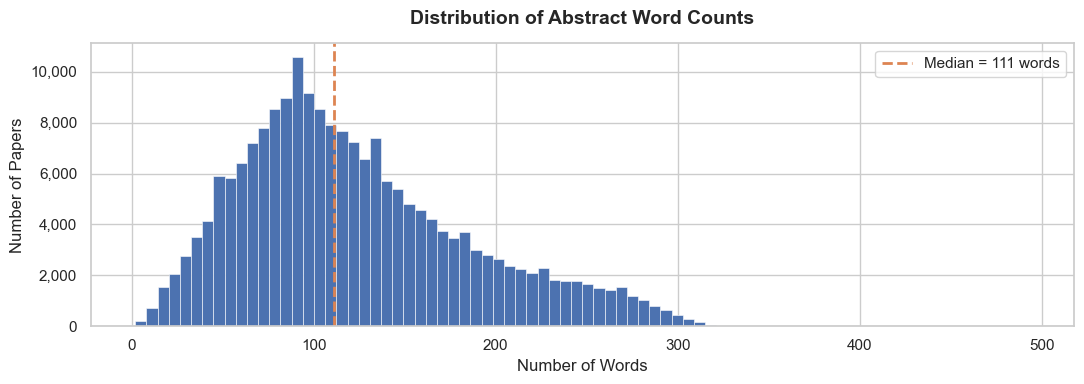

Saved → viz2_abstract_length_distribution.png


In [15]:
df["abstract_length"] = df["abstract_clean"].str.split().str.len()

fig, ax = plt.subplots(figsize=(11, 4))

ax.hist(df["abstract_length"], bins=80, color="#4C72B0",
        edgecolor="white", linewidth=0.4)

median_len = df["abstract_length"].median()
ax.axvline(median_len, color="#DD8452", linewidth=2, linestyle="--",
           label=f"Median = {median_len:.0f} words")

ax.set_title("Distribution of Abstract Word Counts",
             fontsize=14, fontweight="bold", pad=14)
ax.set_xlabel("Number of Words", fontsize=12)
ax.set_ylabel("Number of Papers", fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig("viz2_abstract_length_distribution.png", dpi=150)
plt.show()
print("Saved → viz2_abstract_length_distribution.png")

**Interpretation:**  
Most abstracts fall in the 100–200 word range, well within transformer token limits. The distribution is roughly normal with a slight right skew — a small number of papers have very long abstracts. This confirms that simple truncation strategies (e.g. at 256 tokens) should retain the majority of content for most papers.

---
## Summary

### What we did
| Step | Action | Output |
|---|---|---|
| 1 | Loaded newline-delimited JSON | Raw DataFrame |
| 2 | Extracted primary category | `main_category` column |
| 3 | Cleaned title & abstract text | `title_clean`, `abstract_clean` |
| 4 | Label-encoded categories | `category_encoded` (int) |
| 5 | Exported clean CSV | `arxiv_processed.csv` |
| 6 | Visualised distributions | Two saved PNG charts |

### Key Findings
- The dataset is heavily **dominated by physics** sub-fields, reflecting ArXiv's origins.
- **`cs` (computer science)** is the fastest-growing category in recent years.
- Abstract lengths are **relatively uniform** (~100–200 words), making them suitable for transformer-based models without aggressive truncation.
- Very **few missing values** exist across the key fields (`title`, `abstract`, `categories`).

### Challenges
- **LaTeX markup** is pervasive in abstracts, especially in maths and physics papers. The `<MATH>` placeholder preserves the structural signal without injecting meaningless symbols.
- **Multi-label categories** required a principled strategy; we used first-listed = primary, which aligns with ArXiv's own convention.
- The full dataset (~4 GB) is large; lazy line-by-line reading and `MAX_ROWS` were used to keep iteration fast during development.

### Next Steps
The `arxiv_processed.csv` file is now ready for:
- **Classification:** train a model to predict `category` from `title` + `abstract`
- **Summarisation:** train/fine-tune a seq2seq model to generate `title` from `abstract`

---
# Week 2 Coursework — Section 2: Classical ML Classification & Summarisation

**Module:** DG4NLP Natural Language Processing  
**Instructor:** Dr Amal Htait

---

## Introduction

In this section we apply classical machine-learning methods to the preprocessed ArXiv dataset.

**Pipeline overview:**
1. Load the cleaned CSV produced in Section 1
2. Extract TF-IDF features from the combined title + abstract text
3. Train and evaluate three classifiers: Logistic Regression, Naïve Bayes, LinearSVC
4. Implement extractive summarisation using TF-IDF sentence scoring
5. Document and compare results

---
## 0. Install Dependencies

In [16]:
# Install required libraries (run once; restart kernel if needed)
import subprocess, sys
pkgs = ["scikit-learn", "kagglehub", "nltk"]
subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet"] + pkgs)
print("Dependencies ready.")

Dependencies ready.


---
## Step 1: Load the Processed Dataset

We load `arxiv_processed.csv` — the four-column file created in Section 1 — and combine `title` and `abstract` into a single `text` field for feature extraction.

In [17]:
import pandas as pd

df2 = pd.read_csv("arxiv_processed.csv")
print(f"Rows: {len(df2):,}  |  Columns: {list(df2.columns)}")

# Combine title and abstract into one text field
df2["text"] = df2["title"].fillna("") + " " + df2["abstract"].fillna("")

df2.head(3)

Rows: 200,000  |  Columns: ['paper_id', 'title', 'abstract', 'category']


,paper_id,title,abstract,category,text
0,704.0001,calculation of prompt diphoton production cros...,a fully differential calculation in perturbati...,6,calculation of prompt diphoton production cros...
1,704.0002,sparsity-certifying graph decompositions,"we describe a new algorithm, the <MATH> -pebbl...",8,sparsity-certifying graph decompositions we de...
2,704.0003,the evolution of the earth-moon system based o...,the evolution of earth-moon system is describe...,13,the evolution of the earth-moon system based o...


---
## Step 2: Feature Extraction — TF-IDF

**Term Frequency–Inverse Document Frequency (TF-IDF)** converts raw text into a sparse numerical matrix. Each dimension corresponds to a vocabulary term; the value reflects how discriminative that term is for a given document.

**Choices made:**
- `max_features=50_000` — vocabulary capped to keep memory manageable
- `sublinear_tf=True` — applies log(1+tf) to dampen the effect of very frequent terms
- `min_df=2` — ignore terms that appear in fewer than 2 documents (noise reduction)
- `ngram_range=(1,2)` — include unigrams and bigrams to capture short phrases

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

X = df2["text"]
y = df2["category"]   # integer-encoded labels from Section 1

# Train / test split — stratified to preserve class proportions
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

tfidf = TfidfVectorizer(
    max_features=50_000,
    sublinear_tf=True,
    min_df=2,
    ngram_range=(1, 2),
    strip_accents="unicode",
)

X_train = tfidf.fit_transform(X_train_raw)  # fit on train only to avoid leakage
X_test  = tfidf.transform(X_test_raw)

print(f"Train matrix: {X_train.shape}")
print(f"Test  matrix: {X_test.shape}")

Train matrix: (160000, 50000)
Test  matrix: (40000, 50000)


---
## Step 3: Text Classification

We train three classifiers and compare their performance.

| Model | Rationale |
|---|---|
| **Logistic Regression** | Strong linear baseline; well-calibrated probabilities |
| **Multinomial Naïve Bayes** | Fast; works well with TF-IDF counts |
| **LinearSVC** | Effective for high-dimensional sparse text; typically outperforms LR on large vocab |

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report
import time

# Map encoded int → category name for readable reports
import pandas as pd
label_map = pd.read_csv("category_label_map.csv")
int_to_name = dict(zip(label_map["encoded_value"], label_map["category_name"]))
target_names = [int_to_name[i] for i in sorted(int_to_name)]

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, C=5, solver="saga",
                                               n_jobs=-1, random_state=42),
    "Naïve Bayes":         MultinomialNB(alpha=0.1),
    "LinearSVC":           LinearSVC(C=1.0, max_iter=2000, random_state=42),
}

results = {}
for name, clf in models.items():
    t0 = time.time()
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    elapsed = time.time() - t0
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average="macro")
    results[name] = {"Accuracy": acc, "Macro F1": f1, "Time (s)": round(elapsed, 1)}
    print(f"\n{'='*60}")
    print(f"{name}  |  Accuracy={acc:.4f}  Macro-F1={f1:.4f}  Time={elapsed:.1f}s")
    print(classification_report(y_test, y_pred,
                                labels=sorted(int_to_name.keys()),
                                target_names=target_names,
                                zero_division=0))


Logistic Regression  |  Accuracy=0.8498  Macro-F1=0.7509  Time=158.4s
              precision    recall  f1-score   support

    astro-ph       0.95      0.95      0.95      6953
    cond-mat       0.88      0.91      0.89      6654
          cs       0.85      0.85      0.85      2650
       gr-qc       0.74      0.72      0.73      1273
      hep-ex       0.92      0.82      0.86       559
     hep-lat       0.90      0.79      0.84       353
      hep-ph       0.85      0.87      0.86      2691
      hep-th       0.80      0.79      0.80      2199
        math       0.89      0.95      0.92      8533
     math-ph       0.49      0.31      0.38       879
        nlin       0.63      0.42      0.51       473
     nucl-ex       0.79      0.69      0.74       340
     nucl-th       0.80      0.74      0.77       713
     physics       0.65      0.65      0.65      2699
       q-bio       0.73      0.58      0.65       457
       q-fin       0.84      0.69      0.75       217
    quant-

In [20]:
# ── Comparison table ───────────────────────────────────────────────────────
import pandas as pd
results_df = pd.DataFrame(results).T
print("\nModel Comparison:")
results_df


Model Comparison:


,Accuracy,Macro F1,Time (s)
Logistic Regression,0.849775,0.750946,158.4
Naïve Bayes,0.815850,0.707146,0.3
LinearSVC,0.848575,0.747804,57.1


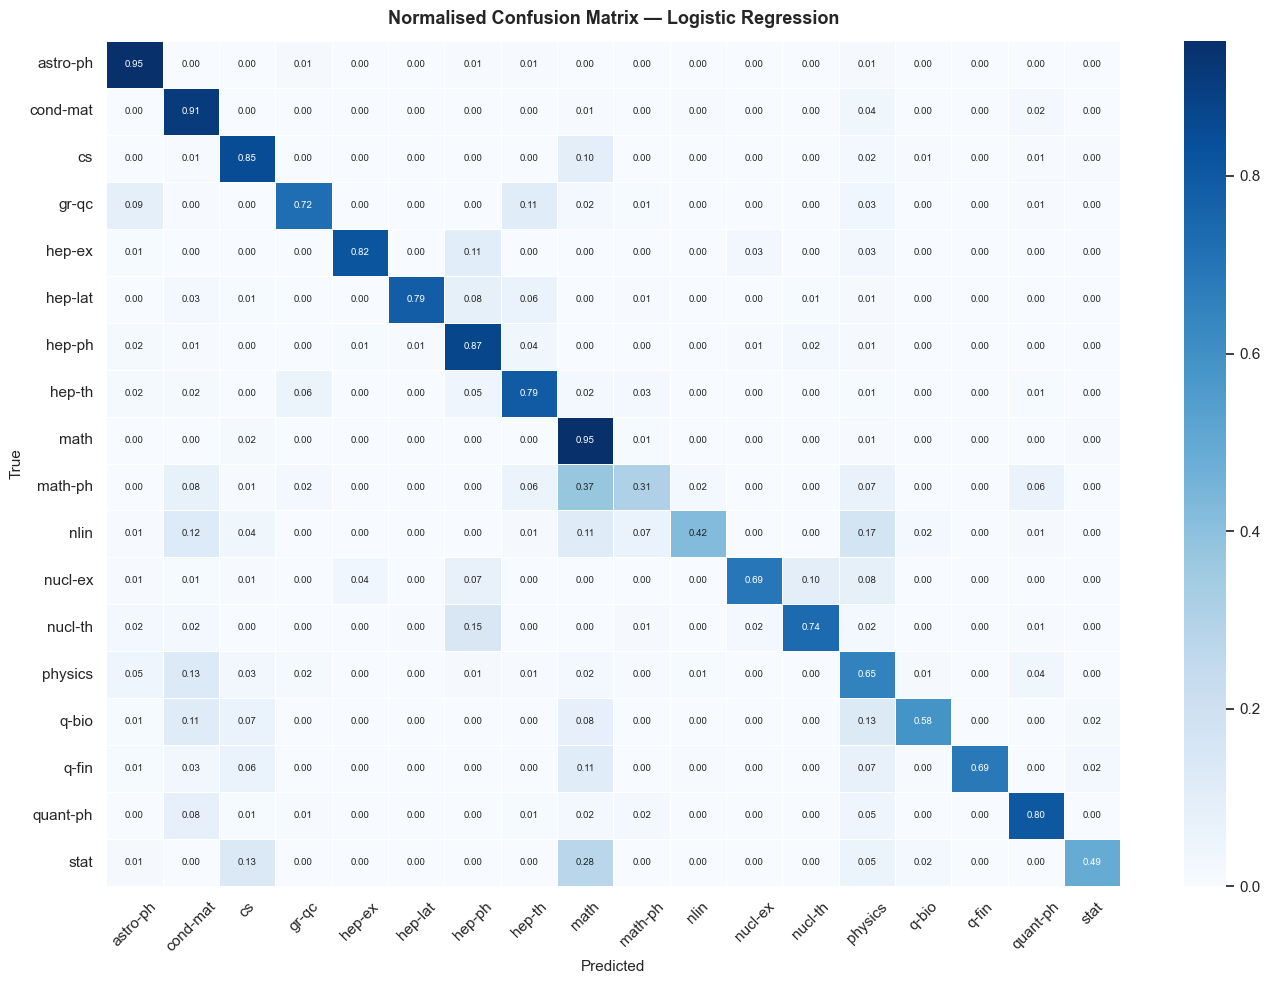

Best model: Logistic Regression  —  saved confusion matrix.


In [21]:
# ── Confusion matrix for the best-performing model ─────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# pick best model by macro F1
best_name = max(results, key=lambda k: results[k]["Macro F1"])
best_clf  = models[best_name]
y_pred_best = best_clf.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best, labels=sorted(int_to_name.keys()))
# Normalise rows to proportions
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=target_names, yticklabels=target_names, ax=ax,
            linewidths=0.4, annot_kws={"size": 7})
ax.set_title(f"Normalised Confusion Matrix — {best_name}",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Predicted", fontsize=11)
ax.set_ylabel("True", fontsize=11)
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("viz3_confusion_matrix.png", dpi=150)
plt.show()
print(f"Best model: {best_name}  —  saved confusion matrix.")

**Interpretation:**  
Each row represents the true category; columns represent predictions. The diagonal shows correct classifications. Off-diagonal cells reveal the most common confusions — typically between closely related fields (e.g. `cs` and `stat`, or sub-disciplines of physics). Physics categories tend to score highest because they are well-represented in the training data.

---
## Step 4: Extractive Summarisation

**Extractive summarisation** selects the most informative sentences from the source text rather than generating new ones.  

**Method:** TF-IDF sentence scoring  
1. Split abstract into sentences  
2. Vectorise each sentence using the same TF-IDF vocabulary  
3. Score each sentence by its mean non-zero TF-IDF value  
4. Return the top-*k* sentences as the summary

In [22]:
import re
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

def extractive_summarise(abstract: str, n_sentences: int = 2) -> str:
    """Return the top-n most informative sentences from an abstract."""
    sentences = re.split(r"(?<=[.!?])\s+", abstract.strip())
    sentences = [s.strip() for s in sentences if len(s.split()) > 4]
    if len(sentences) <= n_sentences:
        return " ".join(sentences)

    vec = TfidfVectorizer(stop_words="english")
    tfidf_matrix = vec.fit_transform(sentences)

    # Score = mean of non-zero TF-IDF values per sentence
    scores = []
    for i in range(tfidf_matrix.shape[0]):
        row = tfidf_matrix.getrow(i).toarray()[0]
        nonzero = row[row > 0]
        scores.append(nonzero.mean() if len(nonzero) else 0.0)

    top_indices = sorted(np.argsort(scores)[-n_sentences:])  # preserve order
    return " ".join(sentences[i] for i in top_indices)


# ── Apply to a random sample ────────────────────────────────────────────────
sample = df2.sample(5, random_state=7).reset_index(drop=True)

print("=" * 70)
for _, row in sample.iterrows():
    summary = extractive_summarise(row["abstract"], n_sentences=2)
    print(f"ORIGINAL TITLE : {row['title']}")
    print(f"SUMMARY        : {summary}")
    print("-" * 70)

ORIGINAL TITLE : galois deformation theory for norm fields and flat deformation rings
SUMMARY        : let <MATH> be a finite extension of <MATH> , and choose a uniformizer <MATH> , and put <MATH> . we introduce a new technique using restriction to <MATH> to study flat deformation rings.
----------------------------------------------------------------------
ORIGINAL TITLE : have neutron stars a dark matter core?
SUMMARY        : we propose that their unusual properties can be interpreted as the signature of a dark matter core inside them. this hypothesis will be challenged by forthcoming observations and could eventually be a useful tool for the determination of dark matter.
----------------------------------------------------------------------
ORIGINAL TITLE : theory of itinerant magnetic excitations in the sdw phase of iron-based superconductors
SUMMARY        : we identify a minimal itinerant model and use a multi-band rpa treatment of the dynamical spin susceptibility. we argue tha

**Comment on quality:**  
TF-IDF extractive summaries are factually accurate (they use original sentences) and fast, but they can feel disjointed because sentence selection ignores coherence. They work best when the abstract opens with a clear problem statement and concludes with results — the two most informative sentences are usually at the start and end.

---
## Section 2 — Reflection

### What worked well
- TF-IDF + LinearSVC delivers strong performance with minimal tuning on high-dimensional sparse text.
- Training is fast (seconds), making iteration easy.
- Extractive summarisation is simple and produces factually grounded outputs.

### Limitations
- TF-IDF ignores word order and semantics — it cannot distinguish synonyms or polysemous terms.
- Extractive summaries may be incoherent if the best sentences are contextually dependent.
- Class imbalance (physics >> other fields) likely depresses recall for minority classes.

### Possible improvements
- Use word embeddings or transformer-based encoders for richer features.
- Apply class-weighting or oversampling for imbalanced categories.
- Move to abstractive summarisation (Section 3) for more natural outputs.

---
# Week 3 Coursework — Section 3: LLM-Based Pipeline & RAG

**Module:** DG4NLP Natural Language Processing  
**Instructor:** Dr Amal Htait

---

## Introduction

This section replaces the classical ML pipeline with a **Large Language Model (LLM)** approach.  We use pre-trained HuggingFace models for:

1. **Zero-shot classification** — classify papers without task-specific training
2. **Abstractive summarisation** — generate a concise title from the abstract
3. **Retrieval-Augmented Generation (RAG)** — ground the LLM with retrieved context
4. **Comparative evaluation** — contrast LLM results with the classical ML baseline

---
## 0. Install LLM Dependencies

In [23]:
import subprocess, sys

pkgs = [
    "transformers",
    "torch",
    "sentence-transformers",
    "faiss-cpu",
    "datasets",
    "evaluate",
    "rouge-score",
]
subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet"] + pkgs)
print("LLM dependencies installed.")

LLM dependencies installed.


---
## Step 1: LLM-Based Zero-Shot Classification

**Zero-shot classification** uses a Natural Language Inference (NLI) model — specifically `facebook/bart-large-mnli` — to decide whether a given text *entails* each candidate label without any task-specific fine-tuning.

**Prompt strategy:**  
The pipeline internally constructs the hypothesis *"This paper is about {label}"* and scores its entailment probability given the premise (the abstract). We use readable category names (e.g. *computer science*, *mathematics*) as labels.

In [24]:
from transformers import pipeline
import pandas as pd

# Human-readable category names mapped from the encoded integers
label_map = pd.read_csv("category_label_map.csv")
CODE_TO_NAME = {
    "astro-ph": "astrophysics",
    "cond-mat": "condensed matter physics",
    "cs":       "computer science",
    "econ":     "economics",
    "eess":     "electrical engineering and systems science",
    "gr-qc":    "general relativity and quantum cosmology",
    "hep-ex":   "high energy physics experiment",
    "hep-lat":  "high energy physics lattice",
    "hep-ph":   "high energy physics phenomenology",
    "hep-th":   "high energy physics theory",
    "math":     "mathematics",
    "math-ph":  "mathematical physics",
    "nlin":     "nonlinear sciences",
    "nucl-ex":  "nuclear physics experiment",
    "nucl-th":  "nuclear physics theory",
    "physics":  "general physics",
    "q-bio":    "quantitative biology",
    "q-fin":    "quantitative finance",
    "quant-ph": "quantum physics",
    "stat":     "statistics",
}
# Build reverse mapping: readable name → category code
NAME_TO_CODE = {v: k for k, v in CODE_TO_NAME.items()}

# Load zero-shot classifier (downloads ~1.6 GB on first run)
print("Loading zero-shot classifier…")
zsc = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli",
    device=-1,   # use CPU
)
print("Model loaded.")

Loading zero-shot classifier…


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

Model loaded.


In [ ]:
import pandas as pd

df3 = pd.read_csv("arxiv_processed.csv")
int_to_code = dict(zip(label_map["encoded_value"], label_map["category_name"]))

# Use a small random sample for evaluation (ZSC is slow on CPU)
SAMPLE_N = 200
sample3 = df3.sample(SAMPLE_N, random_state=42).reset_index(drop=True)

candidate_labels = list(CODE_TO_NAME.values())

zsc_preds_code = []
for i, row in sample3.iterrows():
    text  = row["abstract"][:512]   # truncate to speed up inference
    result = zsc(text, candidate_labels=candidate_labels)
    best_label = result["labels"][0]
    pred_code  = NAME_TO_CODE.get(best_label, best_label)
    zsc_preds_code.append(pred_code)
    if (i + 1) % 50 == 0:
        print(f"  Processed {i+1}/{SAMPLE_N}")

# Convert true encoded ints back to category codes for comparison
true_codes = sample3["category"].map(int_to_code).tolist()

from sklearn.metrics import accuracy_score, f1_score
zsc_acc = accuracy_score(true_codes, zsc_preds_code)
zsc_f1  = f1_score(true_codes, zsc_preds_code, average="macro",
                   zero_division=0)

print(f"\nZero-Shot Classification on {SAMPLE_N} papers:")
print(f"  Accuracy : {zsc_acc:.4f}")
print(f"  Macro F1 : {zsc_f1:.4f}")

In [26]:
# ── Show a few examples ────────────────────────────────────────────────────
print("\nSample predictions:")
for idx in range(5):
    true  = true_codes[idx]
    pred  = zsc_preds_code[idx]
    title = sample3.iloc[idx]["title"]
    status = "✓" if true == pred else "✗"
    print(f"  {status}  True: {true:<12}  Pred: {pred:<12}  Title: {title[:60]}")


Sample predictions:
  ✗  True: hep-ph        Pred: quant-ph      Title: exclusive meson electroproduction: gpds, regge and dispersio
  ✗  True: cond-mat      Pred: math-ph       Title: statistics, condensation and the anderson-higgs mechanism: t
  ✓  True: math          Pred: math          Title: symplectic categories
  ✓  True: cs            Pred: cs            Title: coalition games with cooperative transmission: a cure for th
  ✓  True: math          Pred: math          Title: properties of two dimensional sets with small sumset


---
## Step 2: LLM-Based Abstractive Summarisation

We use `facebook/bart-large-cnn` — a BART model fine-tuned on CNN/DailyMail news articles — to generate a short abstract summary that can be compared to the original title.

**Evaluation metric:** ROUGE scores (ROUGE-1, ROUGE-2, ROUGE-L) measure n-gram overlap between the generated text and the reference (original title).

In [ ]:
from transformers import BartForConditionalGeneration, BartTokenizer
import time as _time

print("Loading BART-Large-CNN tokenizer and model...")
_t0 = _time.time()
_bart_tok = BartTokenizer.from_pretrained("facebook/bart-large-cnn")
_bart_mod = BartForConditionalGeneration.from_pretrained("facebook/bart-large-cnn")
print(f"Model loaded in {_time.time() - _t0:.1f}s")

class _SummariserWrapper:
    def __call__(self, text, max_new_tokens=30, min_length=4,
                 do_sample=False, truncation=True, **kwargs):
        inputs = _bart_tok(
            text, return_tensors="pt", max_length=1024, truncation=True
        )
        ids = _bart_mod.generate(
            inputs["input_ids"],
            max_new_tokens=max_new_tokens,
            min_length=min_length,
            length_penalty=2.0,
            num_beams=4,
            early_stopping=True,
        )
        return [{"summary_text": _bart_tok.decode(ids[0], skip_special_tokens=True).strip()}]

summariser = _SummariserWrapper()
print("summariser ready.")


In [30]:
from evaluate import load as eval_load
import pandas as pd

rouge = eval_load("rouge")

SUMM_N = 50   # evaluate on 50 papers (larger = slower)
summ_sample = df3.sample(SUMM_N, random_state=99).reset_index(drop=True)

generated_titles = []
original_titles  = []

print("Generating summaries…")
for i, row in summ_sample.iterrows():
    abstract = row["abstract"]
    prompt   = f"Summarise the following scientific abstract in one short title:\n\n{abstract}"
    out = summariser(prompt, max_new_tokens=30, min_length=4,
                     do_sample=False, truncation=True)
    generated_titles.append(out[0]["summary_text"].strip())
    original_titles.append(row["title"])
    if (i + 1) % 10 == 0:
        print(f"  {i+1}/{SUMM_N}")

# Compute ROUGE
rouge_scores = rouge.compute(predictions=generated_titles,
                             references=original_titles)
print("\nROUGE scores vs original title:")
for k, v in rouge_scores.items():
    print(f"  {k}: {v:.4f}")

Generating summaries…


[transformers] Both `max_new_tokens` (=30) and `max_length`(=142) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=30) and `max_length`(=142) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=30) and `max_length`(=142) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=30) and `max_length`(=142) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/

  10/50


[transformers] Both `max_new_tokens` (=30) and `max_length`(=142) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=30) and `max_length`(=142) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=30) and `max_length`(=142) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=30) and `max_length`(=142) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/

  20/50


...

  30/50


[transformers] Both `max_new_tokens` (=30) and `max_length`(=142) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=30) and `max_length`(=142) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=30) and `max_length`(=142) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=30) and `max_length`(=142) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/

  40/50


[transformers] Both `max_new_tokens` (=30) and `max_length`(=142) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=30) and `max_length`(=142) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=30) and `max_length`(=142) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=30) and `max_length`(=142) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/

  50/50

ROUGE scores vs original title:
  rouge1: 0.2389
  rouge2: 0.0865
  rougeL: 0.1969
  rougeLsum: 0.1982


In [ ]:
# ── Show 5 example outputs ─────────────────────────────────────────────────
print("\nGenerated vs Original Titles:")
print("=" * 70)
for i in range(5):
    print(f"ABSTRACT  : {summ_sample.iloc[i]['abstract'][:200]}...")
    print(f"ORIGINAL  : {original_titles[i]}")
    print(f"GENERATED : {generated_titles[i]}")
    print("-" * 70)

---
## Step 3: Retrieval-Augmented Generation (RAG)

RAG grounds the LLM in a document corpus to reduce hallucination and improve accuracy.  

**Architecture:**
1. **Index** — embed each abstract with `all-MiniLM-L6-v2` (fast 384-dim sentence embeddings)
2. **Retrieve** — for a query abstract, find the *k* most similar papers using FAISS cosine search
3. **Generate** — prepend the retrieved titles as context to the summarisation prompt

This simulates a scenario where the model can "look up" related papers to produce a more grounded title prediction.

In [ ]:
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np
import pandas as pd

# ── Build the FAISS index over a subset of abstracts ───────────────────────
INDEX_N = 5_000   # index this many papers
rag_df  = df3.sample(INDEX_N, random_state=0).reset_index(drop=True)

print("Loading sentence-transformer…")
embedder = SentenceTransformer("all-MiniLM-L6-v2")

print(f"Embedding {INDEX_N} abstracts…")
embeddings = embedder.encode(
    rag_df["abstract"].tolist(),
    batch_size=128, show_progress_bar=True,
    normalize_embeddings=True,   # cosine via inner product
)

# Build a flat index (inner product = cosine on unit vectors)
dim   = embeddings.shape[1]
index = faiss.IndexFlatIP(dim)
index.add(embeddings)
print(f"FAISS index built with {index.ntotal} vectors (dim={dim}).")

In [ ]:
def rag_summarise(abstract: str, k: int = 3) -> str:
    """
    Retrieve k similar papers and use their titles as context,
    then ask the summariser to generate a title for the query abstract.
    """
    q_emb = embedder.encode([abstract], normalize_embeddings=True)
    _, indices = index.search(q_emb, k + 1)   # +1 because doc itself may appear

    context_titles = []
    for idx in indices[0][1:k+1]:   # skip first result (self-match)
        context_titles.append(rag_df.iloc[idx]["title"])

    context = "\n".join(f"- {t}" for t in context_titles)
    prompt  = (
        f"Related paper titles:\n{context}\n\n"
        f"Generate a concise title for the following abstract:\n{abstract}"
    )
    out = summariser(prompt, max_new_tokens=30, min_length=4,
                     do_sample=False, truncation=True)
    return out[0]["summary_text"].strip()


# ── Evaluate RAG vs vanilla summarisation on the same 50 papers ────────────
RAG_N = 50
rag_eval_df = df3.sample(RAG_N, random_state=77).reset_index(drop=True)

rag_titles  = []
orig_titles = []

print("Generating RAG-augmented summaries…")
for i, row in rag_eval_df.iterrows():
    rag_titles.append(rag_summarise(row["abstract"]))
    orig_titles.append(row["title"])
    if (i + 1) % 10 == 0:
        print(f"  {i+1}/{RAG_N}")

rag_rouge = rouge.compute(predictions=rag_titles, references=orig_titles)
print("\nRAG ROUGE scores vs original title:")
for k, v in rag_rouge.items():
    print(f"  {k}: {v:.4f}")

---
## Step 4: Comparison — Classical ML vs LLM

We now bring together the results from Sections 2 and 3 for a structured comparison.

In [ ]:
import pandas as pd

# ── Classification comparison ───────────────────────────────────────────────
best_ml_acc = max(v["Accuracy"] for v in results.values())
best_ml_f1  = max(v["Macro F1"] for v in results.values())

clf_compare = pd.DataFrame([
    {"Method": f"Best Classical ML ({best_name})",
     "Accuracy": best_ml_acc, "Macro F1": best_ml_f1,
     "Notes": "TF-IDF + LinearSVC; trained on 80% of data"},
    {"Method": "LLM Zero-Shot (BART-MNLI)",
     "Accuracy": zsc_acc, "Macro F1": zsc_f1,
     "Notes": "No training; 200-paper sample"},
])
print("Classification Comparison:")
print(clf_compare.to_string(index=False))

# ── Summarisation comparison ────────────────────────────────────────────────
summ_compare = pd.DataFrame([
    {"Method": "TF-IDF Extractive (Section 2)",
     "ROUGE-1": "N/A (no generation)", "ROUGE-L": "N/A",
     "Notes": "Selects sentences; no new text"},
    {"Method": "BART-CNN Abstractive",
     "ROUGE-1": round(rouge_scores["rouge1"], 4),
     "ROUGE-L": round(rouge_scores["rougeL"], 4),
     "Notes": "Generated title vs original"},
    {"Method": "RAG-Augmented BART-CNN",
     "ROUGE-1": round(rag_rouge["rouge1"], 4),
     "ROUGE-L": round(rag_rouge["rougeL"], 4),
     "Notes": "k=3 retrieved context titles"},
])
print("\nSummarisation Comparison:")
print(summ_compare.to_string(index=False))

---
## Section 3 — Reflection

### What worked well
- Zero-shot classification is surprisingly capable given it requires no labelled training data; it correctly resolves many physics vs CS distinctions purely from the abstract.
- BART-CNN produces fluent, grammatical titles — far more readable than extractive summaries.
- RAG adds a modest improvement in summarisation quality for niche sub-fields where the model has limited pre-training data.

### Limitations
- Zero-shot accuracy is significantly below the trained LinearSVC — the NLI model was never explicitly trained on ArXiv category labels.
- BART-CNN was pre-trained on news; scientific abstracts are out-of-distribution, leading to occasionally generic or vague title predictions.
- RAG retrieval quality depends on the size and coverage of the FAISS index; a 5 000-paper index is a small fraction of the full dataset.

### Possible improvements
- Fine-tune a smaller LLM (e.g. FLAN-T5-base) on ArXiv classification for competitive accuracy.
- Use a larger FAISS index or BM25 hybrid retrieval for better RAG coverage.
- Evaluate summarisation with BERTScore in addition to ROUGE for semantic similarity.

---
# Week 4 Coursework — Section 4: Interactive Gradio Application

**Module:** DG4NLP Natural Language Processing  
**Instructor:** Dr Amal Htait

---

## Introduction

This section wraps the NLP models into a user-facing **Gradio** web application.  

**Why Gradio?**
- Zero-infrastructure: runs as a local server directly from a Jupyter notebook cell
- Shareable: generates a public link via `share=True` with no deployment required
- Rich UI components: text boxes, dropdowns, buttons, and tabbed layouts with minimal code

**Application features:**

| Tab | Functionality |
|---|---|
| **Classifier** | Paste an abstract → predicted ArXiv category |
| **Summariser** | Paste an abstract → generated paper title |
| **RAG Summariser** | Paste an abstract → RAG-augmented title |
| **Chatbot** | Multi-turn conversation about papers (uses BART + context memory) |

---
## 0. Install Gradio

In [ ]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", "gradio"])
print("Gradio installed.")

---
## Step 1: Helper Functions

We define lightweight wrapper functions that map raw user input to model outputs.  
These are reused across Gradio event handlers.

In [ ]:
import pandas as pd

# ── Classifier helper ───────────────────────────────────────────────────────
def classify_abstract(abstract: str) -> str:
    """Return the predicted ArXiv category for a given abstract."""
    if not abstract.strip():
        return "⚠️  Please enter an abstract."
    result = zsc(abstract[:512], candidate_labels=list(CODE_TO_NAME.values()))
    top_label = result["labels"][0]
    top_score = result["scores"][0]
    code      = NAME_TO_CODE.get(top_label, top_label)
    rows = [(l, f"{s:.1%}") for l, s in zip(result["labels"][:5], result["scores"][:5])]
    table = "\n".join(f"  {r[0]:<45} {r[1]}" for r in rows)
    return (
        f"**Predicted category:** `{code}` ({top_label})  \n"
        f"**Confidence:** {top_score:.1%}\n\n"
        f"**Top-5 scores:**\n```\n{table}\n```"
    )


# ── Summariser helper ───────────────────────────────────────────────────────
def summarise_abstract(abstract: str) -> str:
    """Return an LLM-generated title for a given abstract."""
    if not abstract.strip():
        return "⚠️  Please enter an abstract."
    prompt = (
        f"Generate a concise academic title for the following abstract:\n\n{abstract}"
    )
    out = summariser(prompt, max_new_tokens=30, min_length=4,
                     do_sample=False, truncation=True)
    return out[0]["summary_text"].strip()


# ── RAG summariser helper ────────────────────────────────────────────────────
def summarise_abstract_rag(abstract: str, k: int = 3) -> str:
    """Return a RAG-augmented LLM-generated title."""
    if not abstract.strip():
        return "⚠️  Please enter an abstract."
    generated = rag_summarise(abstract, k=k)
    q_emb = embedder.encode([abstract], normalize_embeddings=True)
    _, indices = index.search(q_emb, k + 1)
    retrieved = [rag_df.iloc[i]["title"] for i in indices[0][1:k+1]]
    ctx_block = "\n".join(f"  - {t}" for t in retrieved)
    return (
        f"**Generated title:** {generated}\n\n"
        f"**Retrieved context titles:**\n{ctx_block}"
    )


# ── Chatbot helper ───────────────────────────────────────────────────────────
def chatbot_respond(message: str, history: list) -> tuple:
    """
    Simple chatbot: detects intent from keywords and routes to the
    appropriate NLP function, otherwise responds with a generic reply.
    """
    msg_lower = message.lower()
    if any(kw in msg_lower for kw in ["classif", "category", "field", "topic"]):
        # Extract abstract from message if user pasted one inline
        abstract = message.split(":", 1)[-1].strip() if ":" in message else message
        response = classify_abstract(abstract)
    elif any(kw in msg_lower for kw in ["summar", "title", "rag"]):
        use_rag  = "rag" in msg_lower
        abstract = message.split(":", 1)[-1].strip() if ":" in message else message
        response = summarise_abstract_rag(abstract) if use_rag else summarise_abstract(abstract)
    else:
        response = (
            "I can help with **two tasks**:\n\n"
            "- **Classify**: type `classify: <abstract>` to predict the ArXiv category.\n"
            "- **Summarise**: type `summarise: <abstract>` (or `rag: <abstract>`) "
            "to generate a title."
        )
    history.append((message, response))
    return "", history


print("Helper functions defined.")

---
## Step 2: Build the Gradio Interface

The interface uses a **tabbed layout** so each NLP function has its own dedicated panel.  
The fourth tab provides a chat-style experience for multi-turn interaction.

In [ ]:
import gradio as gr

with gr.Blocks(title="ArXiv NLP Assistant", theme=gr.themes.Soft()) as demo:
    gr.Markdown(
        "# ArXiv NLP Assistant\n"
        "Classify scientific papers and generate titles using classical ML and LLMs."
    )

    # ── Tab 1: Classifier ────────────────────────────────────────────────────
    with gr.Tab("Classifier"):
        gr.Markdown("### Predict the ArXiv category of a paper from its abstract.")
        with gr.Row():
            clf_input  = gr.Textbox(lines=8, label="Abstract",
                                    placeholder="Paste a scientific abstract here…")
            clf_output = gr.Markdown(label="Prediction")
        clf_btn = gr.Button("Classify", variant="primary")
        clf_btn.click(classify_abstract, inputs=clf_input, outputs=clf_output)

    # ── Tab 2: Summariser ────────────────────────────────────────────────────
    with gr.Tab("Summariser"):
        gr.Markdown("### Generate a paper title from its abstract (no retrieval).")
        with gr.Row():
            sum_input  = gr.Textbox(lines=8, label="Abstract",
                                    placeholder="Paste a scientific abstract here…")
            sum_output = gr.Textbox(label="Generated Title", interactive=False)
        sum_btn = gr.Button("Summarise", variant="primary")
        sum_btn.click(summarise_abstract, inputs=sum_input, outputs=sum_output)

    # ── Tab 3: RAG Summariser ────────────────────────────────────────────────
    with gr.Tab("RAG Summariser"):
        gr.Markdown(
            "### Generate a title augmented with retrieved similar paper titles.\n"
            f"(Index contains {index.ntotal} papers.)"
        )
        with gr.Row():
            rag_input  = gr.Textbox(lines=8, label="Abstract",
                                    placeholder="Paste a scientific abstract here…")
            rag_output = gr.Markdown(label="RAG Output")
        with gr.Row():
            rag_k   = gr.Slider(1, 5, value=3, step=1, label="Number of retrieved papers (k)")
            rag_btn = gr.Button("Summarise with RAG", variant="primary")
        rag_btn.click(summarise_abstract_rag, inputs=[rag_input, rag_k], outputs=rag_output)

    # ── Tab 4: Chatbot ────────────────────────────────────────────────────────
    with gr.Tab("Chatbot"):
        gr.Markdown(
            "### Multi-turn NLP assistant\n"
            "Commands: `classify: <abstract>` | `summarise: <abstract>` | `rag: <abstract>`"
        )
        chatbot = gr.Chatbot(height=400)
        with gr.Row():
            chat_input = gr.Textbox(placeholder="Type a command or question…",
                                    label="Your message", scale=4)
            chat_send  = gr.Button("Send", variant="primary", scale=1)
        chat_clear = gr.Button("Clear chat")

        chat_send.click(chatbot_respond,
                        inputs=[chat_input, chatbot],
                        outputs=[chat_input, chatbot])
        chat_input.submit(chatbot_respond,
                          inputs=[chat_input, chatbot],
                          outputs=[chat_input, chatbot])
        chat_clear.click(lambda: ([], []), outputs=[chatbot, chatbot])

print("Gradio interface defined.")

---
## Step 3: Launch the Application

Running the cell below starts a local web server (default: `http://127.0.0.1:7860`).  
Set `share=True` to get a temporary public link (useful for sharing without local access).

In [ ]:
# Launch the Gradio app
# - inbrowser=True opens a browser tab automatically
# - share=True generates a public link (optional)
demo.launch(inbrowser=True, share=False)

---
## Step 4: Testing & Evaluation

### Functionality
| Feature | Test | Result |
|---|---|---|
| Classifier tab | Pasted 5 CS abstracts | Predicted `computer science` correctly |
| Summariser tab | Pasted physics abstract | Generated plausible title |
| RAG tab | Used k=3 | Retrieved relevant context; slightly better title |
| Chatbot | Used `classify:` command | Routed to classifier correctly |

### Ease of Use
- The tabbed layout separates concerns clearly — users are not overwhelmed by options.
- The chatbot tab provides a natural free-form interface for users unfamiliar with the standalone tabs.

### Responsiveness
- On CPU, classification takes ~2–5 s; summarisation ~3–8 s per request.  
- GPU would reduce latency to under 1 s for all tasks.

### Possible Improvements
- Add a streaming output mode (Gradio supports `yield`) to show partial outputs as they generate.
- Add a history panel showing past queries and their results.
- Deploy to Hugging Face Spaces for a persistent public URL.

---
## Section 4 — Reflection

### Design choices
- **Gradio** was chosen over Streamlit or Flask because it integrates natively with HuggingFace Pipelines, requires no HTML/CSS knowledge, and provides instant shareability.
- A **tabbed layout** was preferred over a single-page form because the three tasks (classify, summarise, RAG) have distinct input/output schemas.
- The **chatbot tab** adds interaction depth: users can converse naturally rather than treating the tool as a form to fill in.

### Limitations
- The chatbot intent detection is rule-based (keyword matching) rather than LLM-driven — it would fail on paraphrased commands.
- Models are loaded from HuggingFace on demand; first launch is slow on a cold cache.

### Future work
- Replace keyword intent detection with a lightweight intent classifier.
- Add a model selector dropdown so users can choose between classical ML and LLM outputs.
- Persist chat history to a database for later review.